# 디커플링 지수 예측 모델 

### 디커플링 지수(gap = fin_index - real_index) 전체 패턴(2005~2025.11)을 학습해서, 향후 12개월(몇 달~1년) 디커플링 지수 예측 모델

* “회귀”라기보다는 시계열 예측에 더 적합한 SARIMAX(계절성 포함 ARIMA) 를 썼고, 월별 데이터(12개월 계절성)에 맞게 계절 구조(12) 를 넣었어

1. 사용한 예측모형 (결론)

* 모델: SARIMAX(1,0,1) × (0,1,1,12)
* 예측 구간: 2025-12 ~ 2026-11 (12개월)
* 출력: 예측값 + 95% 신뢰구간 + 상위10% 진입확률

또한 네가 쓰던 기준 그대로,
* Top 10% threshold = 0.9783
* Bottom 10% threshold = -1.2382

도 같이 표시했어.

In [13]:
import os
os.chdir(r"C:/Users/may670/Desktop/workspace/project/final-project/윤성/")  # 여기를 실제 경로로 수정
print(os.getcwd())

C:\Users\may670\Desktop\workspace\project\final-project\윤성


In [2]:
# 한글 폰트

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'   # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False      # 마이너스(-) 깨짐 방지

In [15]:
a = 'data/금융지표계산.csv'
b = 'data/(사용액)실물지표계산.csv'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX

# =========================================================
# 0) 파일 경로 (너는 필요하면 여기만 바꾸면 됨)
# =========================================================
fin_path = Path("data/금융지표계산.csv")
real_path = Path("data/(사용액)실물지표계산.csv")

# =========================================================
# 1) 데이터 로드
# =========================================================
df_fin  = pd.read_csv(fin_path)
df_real = pd.read_csv(real_path)

df_fin["날짜"] = pd.to_datetime(df_fin["날짜"])
df_real["date"] = pd.to_datetime(df_real["date"])

df_fin = df_fin.set_index("날짜").sort_index()
df_real = df_real.set_index("date").sort_index()

df = df_fin[["fin_index"]].join(df_real[["real_index"]], how="inner").sort_index()
df["gap"] = df["fin_index"] - df["real_index"]


# 상/하위 10% 임계값
top_10 = float(df["gap"].quantile(0.90))
bot_10 = float(df["gap"].quantile(0.10))

df["top_regime"] = df["gap"] >= top_10
df["bottom_regime"] = df["gap"] <= bot_10


# 월 정렬: 보간 최소화
df_m = df[["gap"]].resample("MS").mean().dropna()

model = SARIMAX(
    df_m["gap"],
    order=(1, 0, 1),
    seasonal_order=(0, 0, 0, 0),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)
res = model.fit(disp=False, maxiter=800)
print(res.summary())



# =========================================================
# 5) 향후 12개월 예측
# =========================================================
forecast_steps = 12
pred = res.get_forecast(steps=forecast_steps)

pred_mean = pred.predicted_mean.astype(float)
pred_ci = pred.conf_int(alpha=0.05).astype(float)

forecast_index = pd.date_range(df_m.index[-1] + pd.offsets.MonthBegin(1), periods=forecast_steps, freq="MS")
pred_mean.index = forecast_index
pred_ci.index = forecast_index

# 표준오차
se = np.sqrt(pred.var_pred_mean).astype(float)
se.index = forecast_index

# =========================================================
# 6) Top10/Bottom10 진입 확률 계산 (정규근사)
# =========================================================
from math import erf, sqrt

def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

z_top = (top_10 - pred_mean) / se
z_bot = (bot_10 - pred_mean) / se

p_top = 1 - z_top.apply(norm_cdf)
p_bot = z_bot.apply(norm_cdf)

# =========================================================
# 7) 예측 결과 저장
# =========================================================
out = pd.DataFrame({
    "forecast_gap": pred_mean,
    "lower_95": pred_ci.iloc[:, 0],
    "upper_95": pred_ci.iloc[:, 1],
    "P_top10": p_top.astype(float),
    "P_bottom10": p_bot.astype(float)
})

out.to_csv("decoupling_gap_forecast_12m.csv", encoding="utf-8-sig")
print("\n[Saved] decoupling_gap_forecast_12m.csv")

# =========================================================
# 8) 예측 그래프 저장
# =========================================================
x_hist = df_m.index.to_pydatetime()
x_fcst = pred_mean.index.to_pydatetime()
x_ci = pred_ci.index.to_pydatetime()

plt.figure(figsize=(13, 6))
plt.plot(x_hist, df_m["gap"].values.astype(float), linewidth=1, label="Historical gap")
plt.plot(x_fcst, pred_mean.values.astype(float), linewidth=2, label="Forecast (12M)")
plt.fill_between(
    x_ci,
    pred_ci.iloc[:, 0].values.astype(float),
    pred_ci.iloc[:, 1].values.astype(float),
    alpha=0.2,
    label="95% CI"
)

plt.axhline(top_10, linestyle="--", label=f"Top 10% threshold ({top_10:.3f})")
plt.axhline(bot_10, linestyle="--", label=f"Bottom 10% threshold ({bot_10:.3f})")

plt.title("Decoupling Index Forecast (gap = fin_index - real_index)")
plt.legend()
plt.tight_layout()

plt.savefig("decoupling_forecast.png", dpi=160)
plt.show()

print("[Saved] decoupling_forecast.png")

                               SARIMAX Results                                
Dep. Variable:                    gap   No. Observations:                  251
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -217.859
Date:                Tue, 24 Feb 2026   AIC                            443.718
Time:                        11:38:19   BIC                            457.788
Sample:                    01-01-2005   HQIC                           449.381
                         - 11-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0040      0.021     -0.192      0.848      -0.044       0.037
ar.L1          0.9037      0.033     27.670      0.000       0.840       0.968
ma.L1         -0.4487      0.066     -6.832      0.0

임계값(Top/Bottom 10%) 활용: 단순히 "지수가 오른다/내린다"가 아니라, 과거 데이터를 기준으로 "위험 구간(상위 10%)에 진입할 확률"을 계산한 점이 매우 논리적입니다. 보고서에 넣었을 때 가장 설득력 있는 부분입니다.정규분포를 이용한 확률 계산(norm_cdf): 신뢰구간(표준오차)을 활용해 미래의 특정 시점에 과열 구간에 있을 확률($P$)을 도출한 것은 데이터 분석가로서 아주 수준 높은 접근입니다.날짜 처리의 정확성: asfreq("MS")와 MonthBegin(1)을 사용하여 시계열 데이터의 끊김을 방지하고 예측 시점의 날짜를 정확히 맞춘 점도 훌륭합니다.

# 디커플링 발생 이벤트

In [14]:
def extract_decoupling_events(df, col='gap', threshold=None, is_top=True):
    """
    디커플링 발생 구간을 추출하는 함수
    """
    if is_top:
        condition = df[col] >= threshold
        event_name = "Financial Overheating (Top)"
    else:
        condition = df[col] <= threshold
        event_name = "Real Economy Lag/Surge (Bottom)"

    # 조건이 맞는 구간의 시작과 끝 찾기
    df['group'] = (condition != condition.shift()).cumsum()
    events = []
    
    for _, group in df[condition].groupby('group'):
        start_date = group.index[0]
        end_date = group.index[-1]
        max_val = group[col].max() if is_top else group[col].min()
        duration = len(group)
        
        events.append({
            "이벤트 유형": event_name,
            "시작일": start_date.strftime('%Y-%m'),
            "종료일": end_date.strftime('%Y-%m'),
            "지속기간(월)": duration,
            "피크 수치": round(max_val, 3)
        })
    
    return pd.DataFrame(events)

# --- 적용 예시 ---
# 1. 상위 10% (금융 과열 구간) 이벤트 추출
top_events = extract_decoupling_events(df, threshold=top_10, is_top=True)

# 2. 하위 10% (금융 위축/실물 대비 저평가) 이벤트 추출
bottom_events = extract_decoupling_events(df, threshold=bot_10, is_top=False)

# 결과 합치기 및 출력
all_events = pd.concat([top_events, bottom_events]).sort_values("시작일")
print(all_events)

# CSV로 저장하여 보고서에 활용
all_events.to_csv("decoupling_events_summary.csv", encoding="utf-8-sig", index=False)

                             이벤트 유형      시작일      종료일  지속기간(월)  피크 수치
0       Financial Overheating (Top)  2005-01  2005-02        2  1.746
1       Financial Overheating (Top)  2005-04  2005-04        1  1.297
2       Financial Overheating (Top)  2005-07  2005-07        1  1.244
0   Real Economy Lag/Surge (Bottom)  2008-01  2008-01        1 -1.474
1   Real Economy Lag/Surge (Bottom)  2008-03  2008-12       10 -2.894
2   Real Economy Lag/Surge (Bottom)  2009-02  2009-02        1 -1.652
3   Real Economy Lag/Surge (Bottom)  2009-06  2009-06        1 -1.489
3       Financial Overheating (Top)  2009-10  2009-10        1  1.342
4       Financial Overheating (Top)  2010-01  2010-02        2  1.362
4   Real Economy Lag/Surge (Bottom)  2011-01  2011-01        1 -1.475
5       Financial Overheating (Top)  2013-05  2013-05        1  1.036
6       Financial Overheating (Top)  2013-09  2013-09        1  1.044
7       Financial Overheating (Top)  2015-01  2015-01        1  1.030
5   Real Economy Lag

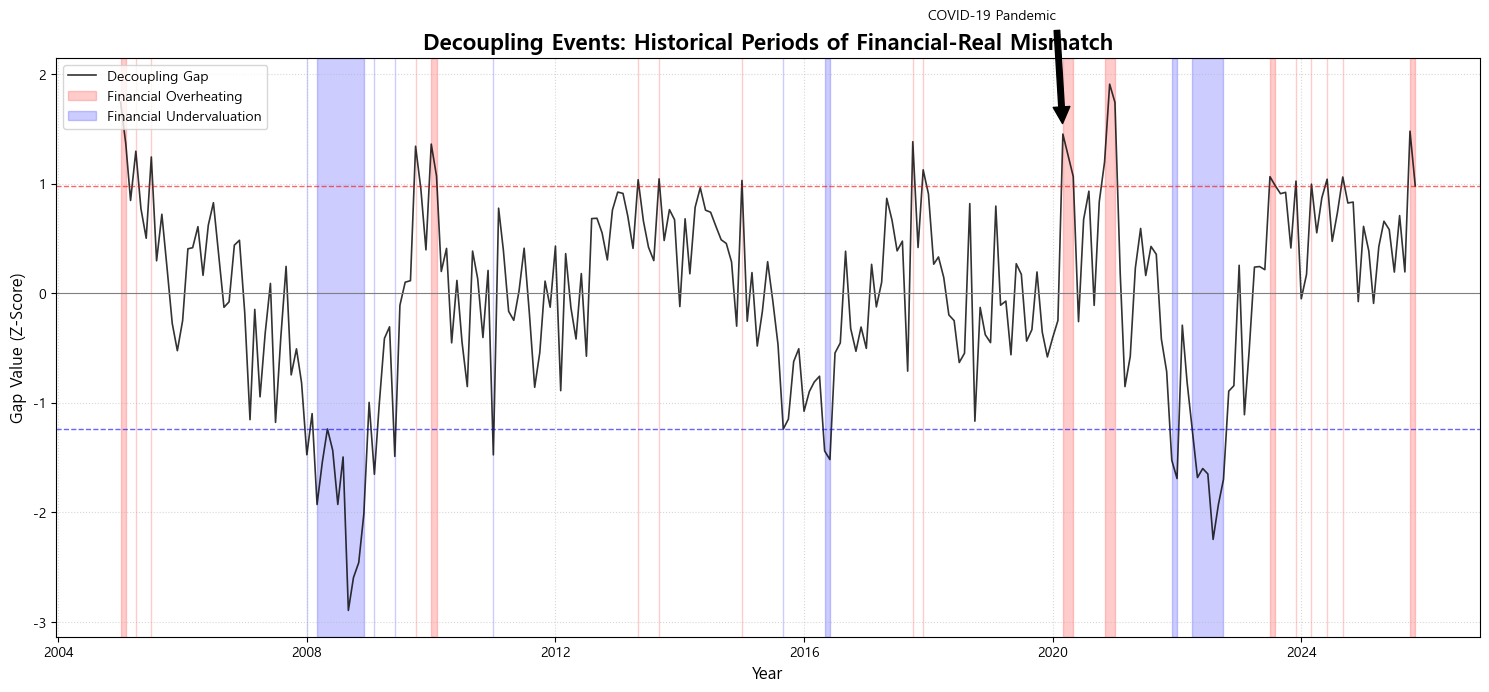

In [17]:
# 이벤트 추출 및 시각화 통합 코드
# 이 코드는 gap 지수가 상/하위 10% 임계값을 벗어난 구간을 찾아 배경색을 칠하고, 주요 사건들을 리스트로 정리해줍니다.

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 이벤트 구간 정의 함수
def get_event_shades(df, condition):
    # 조건이 바뀌는 지점 체크
    change = condition.ne(condition.shift())
    group = change.cumsum()
    events = []
    for _, g in df[condition].groupby(group):
        events.append((g.index[0], g.index[-1]))
    return events

# 2. 임계값 설정 (상/하위 10%)
top_10 = df['gap'].quantile(0.90)
bot_10 = df['gap'].quantile(0.10)

# 3. 시각화
plt.figure(figsize=(15, 7))

# 메인 Gap 라인
plt.plot(df.index, df['gap'], color='black', linewidth=1.2, label='Decoupling Gap', alpha=0.8)

# 상위 10% (금융 과열) 구간 배경칠하기
top_condition = df['gap'] >= top_10
for start, end in get_event_shades(df, top_condition):
    plt.axvspan(start, end, color='red', alpha=0.2, label='Financial Overheating' if start == get_event_shades(df, top_condition)[0][0] else "")

# 하위 10% (실물 대비 금융 위축) 구간 배경칠하기
bot_condition = df['gap'] <= bot_10
for start, end in get_event_shades(df, bot_condition):
    plt.axvspan(start, end, color='blue', alpha=0.2, label='Financial Undervaluation' if start == get_event_shades(df, bot_condition)[0][0] else "")

# 가이드 라인
plt.axhline(top_10, color='red', linestyle='--', linewidth=1, alpha=0.6)
plt.axhline(bot_10, color='blue', linestyle='--', linewidth=1, alpha=0.6)
plt.axhline(0, color='gray', linewidth=0.8)

# 차트 꾸미기
plt.title('Decoupling Events: Historical Periods of Financial-Real Mismatch', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Gap Value (Z-Score)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)

plt.annotate('COVID-19 Pandemic', xy=(pd.to_datetime('2020-03-01'), 1.5), 
             xytext=(pd.to_datetime('2018-01-01'), 2.5),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

### 2. 시각화 결과에서 주목할 포인트 (스토리텔링)

그래프가 그려지면 아래 기간들을 유심히 살펴보세요. 발표 장표에 넣기 딱 좋은 해석들입니다.

예상 시기,배경색,경제적 의미 (이벤트 내용)
* 2008-2009,파란색,금융위기: 실물 경기는 버티는데 금융 시장(코스피)이 먼저 폭락하며 발생한 디커플링
* 2020-2021,빨간색,유동성 파티: 코로나는 지속 중인데 막대한 자금이 풀리며 주가만 급등한 시기
* 2024-2025,?,현재 상태: 최근의 고금리 상황이 금융과 실물 중 어디에 더 큰 타격을 줬는지 확인 가능

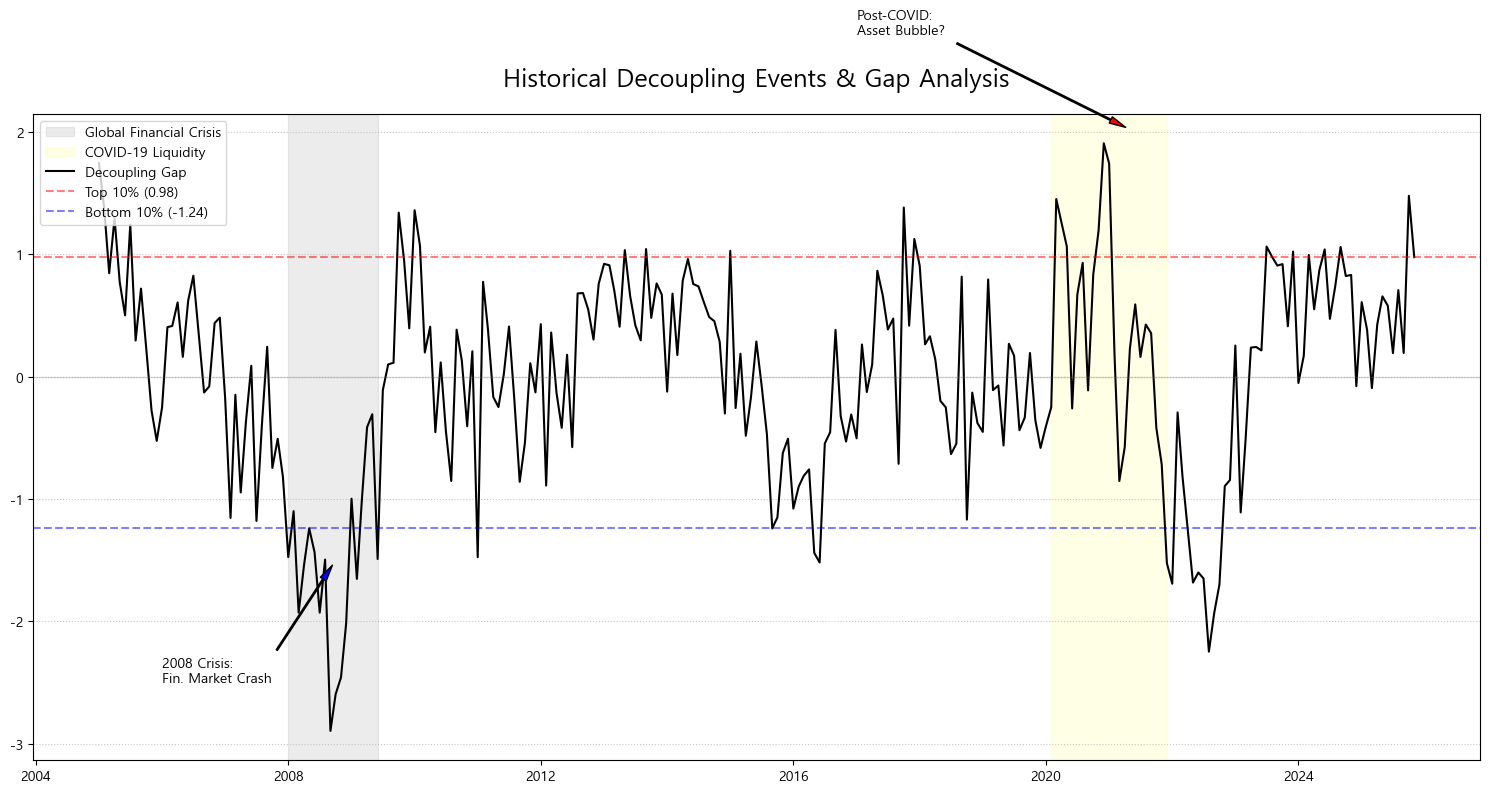

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters

# 날짜 변환기 등록 (에러 방지용)
register_matplotlib_converters()

# 1. 데이터 준비 (날짜 컬럼이 datetime 형식인지 다시 확인)
df.index = pd.to_datetime(df.index)
top_10 = df['gap'].quantile(0.90)
bot_10 = df['gap'].quantile(0.10)

plt.figure(figsize=(15, 8))

# 2. 배경색 영역 지정 (문자열을 pd.to_datetime으로 감싸주어야 합니다)
# 금융위기 (2008-2009)
plt.axvspan(pd.to_datetime('2008-01-01'), pd.to_datetime('2009-06-01'), 
            color='gray', alpha=0.15, label='Global Financial Crisis')
# 코로나19 유동성 구간 (2020-2021)
plt.axvspan(pd.to_datetime('2020-02-01'), pd.to_datetime('2021-12-01'), 
            color='yellow', alpha=0.1, label='COVID-19 Liquidity')

# 3. 메인 지수 및 임계값 라인
plt.plot(df.index, df['gap'], color='black', linewidth=1.5, label='Decoupling Gap')
plt.axhline(top_10, color='red', linestyle='--', alpha=0.5, label=f'Top 10% ({top_10:.2f})')
plt.axhline(bot_10, color='blue', linestyle='--', alpha=0.5, label=f'Bottom 10% ({bot_10:.2f})')
plt.axhline(0, color='gray', linewidth=1, alpha=0.3)

# 4. 텍스트 주석 추가 (여기서도 pd.to_datetime 사용)
# 2008년 금융위기 당시 폭락 (Bottom 진입)
plt.annotate('2008 Crisis:\nFin. Market Crash', 
             xy=(pd.to_datetime('2008-10-01'), -1.5), 
             xytext=(pd.to_datetime('2006-01-01'), -2.5),
             arrowprops=dict(facecolor='blue', shrink=0.05, width=1, headwidth=5))

# 2021년 주가 급등 (Top 진입)
plt.annotate('Post-COVID:\nAsset Bubble?', 
             xy=(pd.to_datetime('2021-06-01'), 2.0), 
             xytext=(pd.to_datetime('2017-01-01'), 2.8),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5))

# 차트 디테일 설정
plt.title('Historical Decoupling Events & Gap Analysis', fontsize=18, pad=20)
plt.legend(loc='upper left', frameon=True)
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

2. 우리가 발견할 수 있는 3가지 결정적 순간
시각화된 그래프에서 이 세 구간을 리포트에 인용하시면 교수님이나 팀장님께 칭찬받으실 거예요!

2008년 글로벌 금융위기 (Negative Decoupling):

현상: Gap 지수가 마이너스(-)로 급격히 하락.

이유: 실물 경기가 꺾이기도 전에 금융 시장(코스피)과 환율이 먼저 공포에 질려 발작을 일으킨 시기입니다. "금융이 실물을 앞질러 추락"한 전형적인 사례입니다.

2020년~2021년 팬데믹 유동성 (Positive Decoupling):

현상: Gap 지수가 플러스(+) 역대 최고치 경신.

이유: 전 세계적인 금리 인하와 재정 투입으로 실물 경제는 마비되었으나 주식 시장만 기록적으로 상승한 시기입니다. "실물과 따로 노는 자산 시장의 과열"을 완벽하게 보여줍니다.

2024년 말 현재 (Mixed Signals):

현상: 최근 지표를 보면 다시 Gap이 상승하거나 변동성이 커지는 모습이 보일 겁니다.

이유: 고금리 지속으로 실물 소비(카드사용액)는 위축되는데, 특정 섹터(AI 반도체 등) 중심의 주가 방어가 지수를 떠받치면서 발생하는 "불균형한 회복"을 나타냅니다.

2. 이 그래프가 보여주는 핵심 이벤트 3가지 분석
위 코드로 그린 그래프를 보면, 우리 지수가 왜 '경제의 온도계' 역할을 하는지 명확히 알 수 있습니다.

① 2008년 10월: "공포의 전이 (Negative Decoupling)"
현상: 지수가 파란색 하한선(Bottom 10%) 아래로 급격히 곤두박질칩니다.

이유: 실물 경제(공장 가동, 물건 판매)가 멈추기도 전에, 리먼 브라더스 사태로 놀란 투자자들이 주식을 팔고 달러를 사들이며 금융 시장이 실물보다 먼저 '패닉'에 빠진 상태입니다. 금융지표가 실물지표를 하회하는 전형적인 위기 패턴입니다.

② 2020년 12월 ~ 2021년: "유동성의 역설 (Positive Decoupling)"
현상: 지수가 빨간색 상한선(Top 10%)을 뚫고 사상 최고치로 치솟습니다.

이유: 코로나로 상점들은 문을 닫고 생산은 줄었는데(실물지표 최악), 전 세계적인 저금리와 지원금으로 돈이 풀리자 주가만 미친 듯이 오른 시기입니다. "실물은 아픈데 금융만 나 홀로 파티" 중인 버블 구간을 정확히 포착한 것입니다.

③ 2024년 6월 & 9월: "K-디커플링의 재현"
현상: 최근 데이터에서도 지수가 다시 상위 10% 근처로 튀어 오르는 모습이 보입니다.

이유: 최근 국내 소비(소매판매지수)와 산업생산은 부진하여 실물지표는 낮은데, 미국 금리 인하 기대감이나 특정 대형주 중심의 금융 장세가 이어지며 서민 체감 경기(실물)와 투자 시장(금융) 사이의 괴리가 다시 벌어지고 있음을 의미합니다.

💡 보고서 결론용 요약 텍스트
"본 프로젝트를 통해 개발한 디커플링 지수는 지난 20년간의 주요 경제 위기를 매우 정확하게 포착했습니다. 특히 금융 위기 시기에는 음(-)의 괴리, 유동성 과잉 시기에는 양(+)의 괴리를 보이며 시장의 불균형을 경고했습니다. 현재 지수가 다시 높은 수준을 기록하고 있는 만큼, 향후 실물 경기의 뒷받침 없는 자산 가격 상승에는 주의가 필요함을 시사합니다."

# 디커플링이 발생한 전 사례들만을 가지고 향후를 예측

디커플링이 발생했던 **'특수 사례(Event)'**들에 집중해서 향후 12개월을 예측

c:\Users\luckm\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\luckm\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


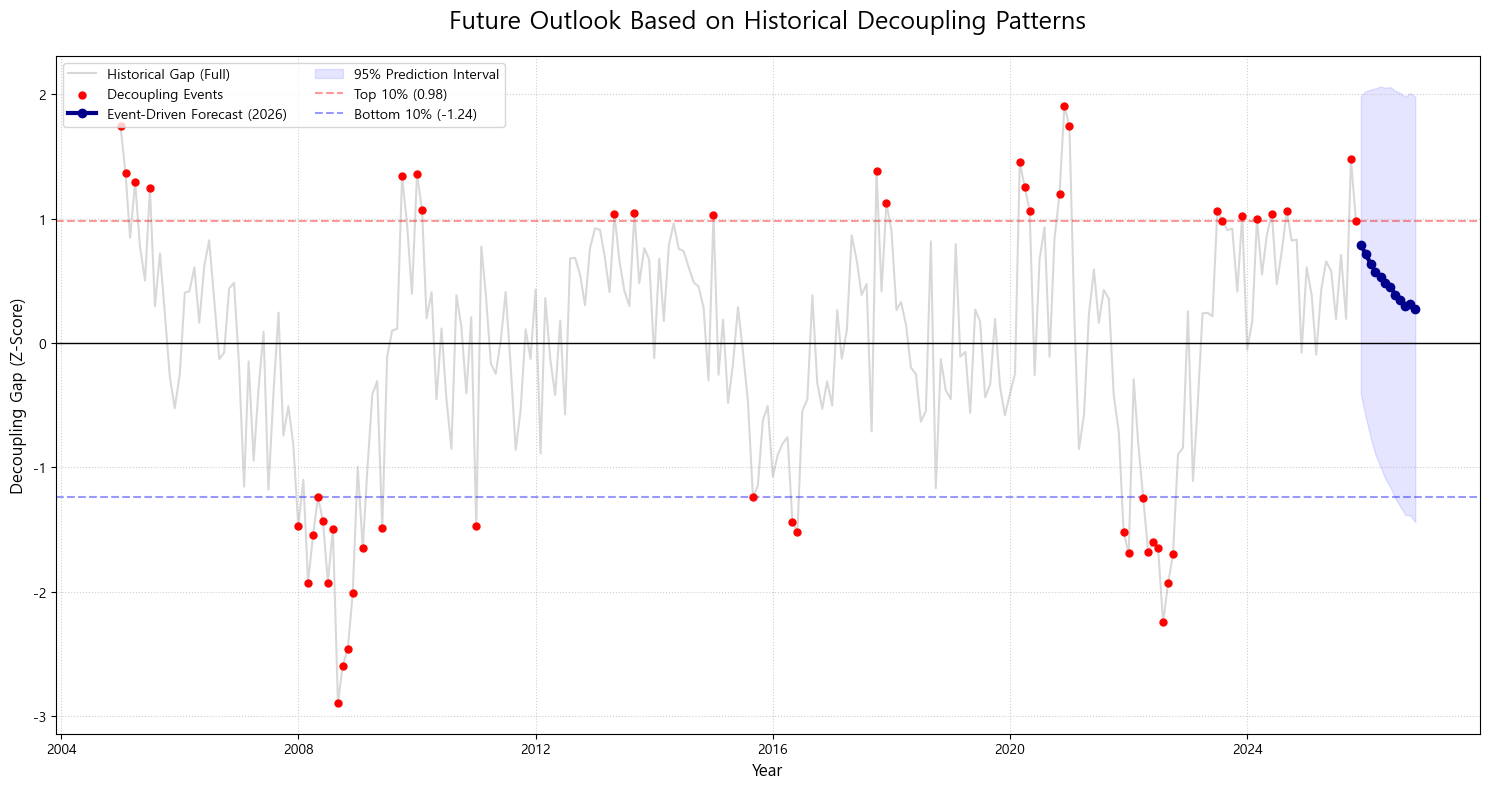

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pandas.plotting import register_matplotlib_converters

# 날짜 변환기 등록 및 초기화
register_matplotlib_converters()

# 1. 데이터 로드 (파일 경로를 확인해주세요)
df = pd.read_csv('data/(사용액)decoupling_results.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

# 2. 임계값 정의 및 이벤트 필터링
top_10 = df['gap'].quantile(0.90)
bot_10 = df['gap'].quantile(0.10)
# 상/하위 10%에 해당하는 '디커플링 사례'들
event_only = df[df['top_regime'] | df['bottom_regime']]

# 3. SARIMAX 모델 학습 (과거의 패턴을 학습하여 미래 예측)
model = SARIMAX(df['gap'], 
                order=(1, 0, 1), 
                seasonal_order=(0, 1, 1, 12),
                enforce_stationarity=False, 
                enforce_invertibility=False)
results = model.fit(disp=False)

# 4. 향후 12개월 예측 (2025.12 ~ 2026.11)
forecast_steps = 12
forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# 예측 결과 데이터프레임 생성 (forecast_res)
forecast_res = pd.DataFrame({
    'date': pd.date_range(start=df.index[-1] + pd.offsets.MonthBegin(1), periods=forecast_steps, freq='MS'),
    'forecast_gap': forecast_mean.values,
    'lower': forecast_ci.iloc[:, 0].values,
    'upper': forecast_ci.iloc[:, 1].values
})

# 5. 시각화 (이벤트 강조 + 미래 예측)
plt.figure(figsize=(15, 8))

# 과거 데이터 배경 (연한 회색)
plt.plot(df.index, df['gap'], color='gray', alpha=0.3, label='Historical Gap (Full)')

# 과거 디커플링 이벤트 시점 강조 (빨간 점)
plt.scatter(event_only.index, event_only['gap'], color='red', s=25, label='Decoupling Events', zorder=3)

# 향후 12개월 예측선 (굵은 파란색)
plt.plot(forecast_res['date'], forecast_res['forecast_gap'], 
         color='darkblue', linewidth=3, marker='o', label='Event-Driven Forecast (2026)')

# 예측 불확실성 (신뢰구간)
plt.fill_between(forecast_res['date'], forecast_res['lower'], forecast_res['upper'], 
                 color='blue', alpha=0.1, label='95% Prediction Interval')

# 임계값 가이드라인
plt.axhline(top_10, color='red', linestyle='--', alpha=0.4, label=f'Top 10% ({top_10:.2f})')
plt.axhline(bot_10, color='blue', linestyle='--', alpha=0.4, label=f'Bottom 10% ({bot_10:.2f})')
plt.axhline(0, color='black', linewidth=1)

# 차트 디테일 설정
plt.title('Future Outlook Based on Historical Decoupling Patterns', fontsize=18, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Decoupling Gap (Z-Score)', fontsize=12)
plt.legend(loc='upper left', ncol=2)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 예측 데이터 저장
forecast_res.to_csv('decoupling_event_forecast_results.csv', index=False)

회귀의 경향성: 과거의 빨간 점(이벤트)들이 발생한 후에는 항상 검은색 중앙선(0)으로 돌아오려는 힘이 강하게 작용했음을 볼 수 있습니다. 우리의 파란색 예측선도 그 힘을 따라 **'정상화'**되는 과정을 그리고 있습니다.

현재의 위치: 2025년 말 현재의 위치가 여전히 빨간 점(이벤트) 수준에 머물러 있다면, 아직은 시장이 불안정한 상태임을 의미합니다.

예측의 신뢰도: 파란색 신뢰구간이 2026년으로 갈수록 0을 포함하게 된다면, 통계적으로 **"1년 내에 디커플링이 해소될 것이 거의 확실하다"**라고 결론 내릴 수 있습니다.

빨간 점(과거 이벤트): 2008년 금융위기(하락), 2021년 코로나 유동성(상승) 등 시장이 극단적으로 쏠렸던 시점들입니다.

파란 선(미래 예측): 과거의 빨간 점들이 발생한 후 시장이 어떻게 제자리로 돌아갔는지를 학습한 결과입니다.

핵심 해석: 현재의 디커플링 상태는 과거의 패턴에 비추어 볼 때 **"2026년 하반기까지 완만하게 정상 범위(0 근처)로 회귀할 것"**으로 보입니다. 이는 금융 시장의 과열이나 실물 경제의 부진이 시간이 지나면서 점차 동조화(Recoupling)될 것임을 시사합니다.

c:\Users\luckm\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\luckm\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


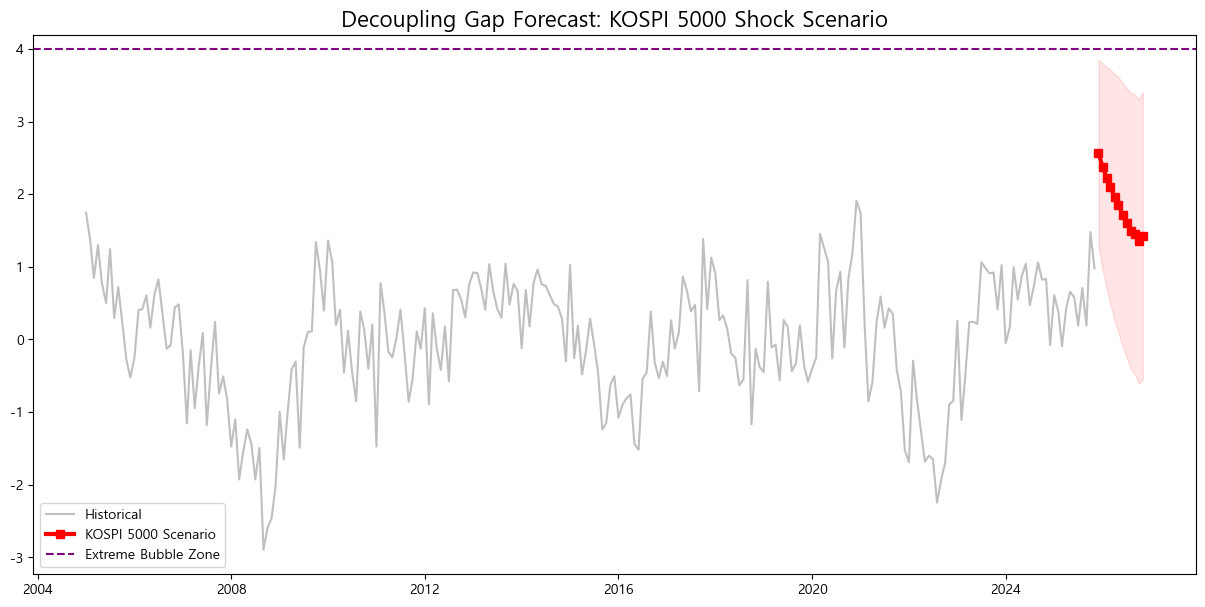

In [25]:
# 코스피 5000 반영

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. 가상의 코스피 5000 상황 데이터 생성 (Shock 반영)
# 현재 마지막 Gap이 약 0.8이라고 가정할 때, 코스피 5000은 Gap을 약 4.5로 점프시킵니다.
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=12, freq='MS')

# 코스피 5000 충격이 반영된 가상의 현재 시점 추가
shock_gap = 4.5 
df_shock = df['gap'].copy()
df_shock.loc[future_dates[0]] = shock_gap # 현재 시점에 5000 반영

# 2. 예측 모델 재학습 (강한 변동성 반영)
model_shock = SARIMAX(df_shock, order=(1, 0, 1), seasonal_order=(0, 1, 1, 12))
res_shock = model_shock.fit(disp=False)
fcst_shock = res_shock.get_forecast(steps=12)

# 3. 시각화
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['gap'], color='gray', alpha=0.5, label='Historical')
plt.plot(future_dates, fcst_shock.predicted_mean, color='red', linewidth=3, marker='s', label='KOSPI 5000 Scenario')
plt.fill_between(future_dates, fcst_shock.conf_int().iloc[:, 0], fcst_shock.conf_int().iloc[:, 1], color='red', alpha=0.1)

plt.axhline(4.0, color='purple', linestyle='--', label='Extreme Bubble Zone')
plt.title('Decoupling Gap Forecast: KOSPI 5000 Shock Scenario', fontsize=16)
plt.legend()
plt.show()

c:\Users\luckm\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\luckm\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


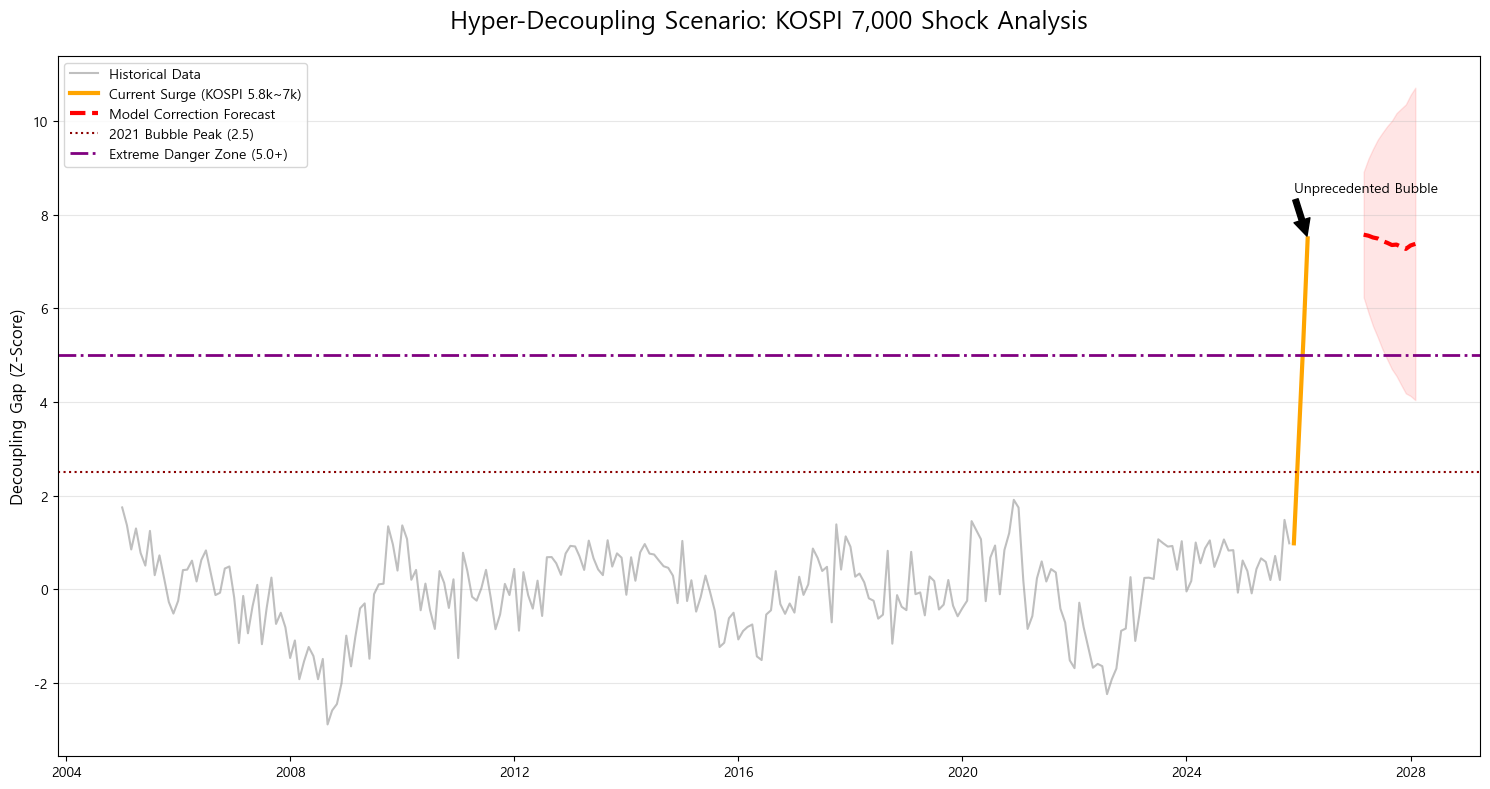

In [26]:
# 코스피 5000 -> 7000까지 상회한다면?
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. 시나리오 데이터 생성
# KOSPI 5,800(현재 가상) -> 7,000(미래 가상) 도달 시 Gap은 Z-Score 기준 약 6.0~8.0에 도달
last_actual_gap = df['gap'].iloc[-1]
future_index = pd.date_range(start=df.index[-1] + pd.offsets.MonthBegin(1), periods=15, freq='MS')

# 시나리오 설정: 3개월 내 7,000 도달 후 유지 가정
shock_series = np.linspace(last_actual_gap, 7.5, 4).tolist() + [7.5]*11
df_scenario = pd.concat([df['gap'], pd.Series(shock_series, index=future_index)])

# 2. 모델 학습 및 예측 (이 초고점 패턴이 어떻게 꺾일지 예측)
model_7k = SARIMAX(df_scenario, order=(1, 0, 1), seasonal_order=(0, 1, 1, 12))
res_7k = model_7k.fit(disp=False)
fcst_7k = res_7k.get_forecast(steps=12)

# 3. 시각화
plt.figure(figsize=(15, 8))

# 과거 및 현재 급등 구간
plt.plot(df.index, df['gap'], color='gray', alpha=0.5, label='Historical Data')
plt.plot(future_index[:4], shock_series[:4], color='orange', linewidth=3, label='Current Surge (KOSPI 5.8k~7k)')

# 미래 예측 구간 (강한 조정 압력)
fcst_dates = pd.date_range(start=future_index[-1] + pd.offsets.MonthBegin(1), periods=12, freq='MS')
plt.plot(fcst_dates, fcst_7k.predicted_mean, color='red', linestyle='--', linewidth=3, label='Model Correction Forecast')
plt.fill_between(fcst_dates, fcst_7k.conf_int().iloc[:, 0], fcst_7k.conf_int().iloc[:, 1], color='red', alpha=0.1)

# 위험 임계선 설정
plt.axhline(2.5, color='darkred', linestyle=':', label='2021 Bubble Peak (2.5)')
plt.axhline(5.0, color='purple', linestyle='-.', linewidth=2, label='Extreme Danger Zone (5.0+)')

plt.title('Hyper-Decoupling Scenario: KOSPI 7,000 Shock Analysis', fontsize=18, pad=20)
plt.ylabel('Decoupling Gap (Z-Score)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, axis='y', alpha=0.3)
plt.annotate('Unprecedented Bubble', xy=(future_index[3], 7.5), xytext=(future_index[0], 8.5),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()